In [95]:
import numpy as np
from numpy.linalg import norm
import matplotlib.pyplot as plt
from datetime import datetime
import pytz

import trajectory as T
from PlanetaryData import Earth, Luna, Sun
from Spice import SpiceImporter
from algorithms import ChristianRobinson
from Constants import RAD_TO_DEG, DEG_TO_RAD

In [96]:
def circle_points(radius, N = 100, position = None):
    p = (0,0) if position is None else position
    t = np.linspace(0, np.pi * 2, N, endpoint=False)
    return [radius * np.cos(t) + p[0], radius * np.sin(t) + p[1]]

def noise(cov):
    return np.random.multivariate_normal(
        mean = np.zeros(cov.shape[0]),
        cov=cov
    )

R_example = np.array([
    [0.5, 0, 0],
    [0, 0.5, 0],
    [0, 0, 0]
])
print(f"Example noise: {noise(R_example)}\nwith R = \n{R_example}")

Example noise: [-0.42774731 -0.1412216   0.        ]
with R = 
[[0.5 0.  0. ]
 [0.  0.5 0. ]
 [0.  0.  0. ]]


In [97]:
spicer = SpiceImporter()
spicer.download_kernels()
spicer.load_kernels()

t = datetime(2026, 6, 13, 11, 25, 00, tzinfo=pytz.utc)

moon_data = spicer.get_state(body_name="MOON", time=t, observer="MOON")
earth_data = spicer.get_state(body_name="EARTH", time=t, observer="MOON")
sun_data = spicer.get_state(body_name="SUN", time=t, observer="MOON")

print(moon_data)
print(earth_data)
print(sun_data)

  naif0012.tls already exists
  gm_de440.tpc already exists
  de440.bsp already exists
Download complete!
Loaded: naif0012.tls
Loaded: gm_de440.tpc
Loaded: de440.bsp
{'name': 'MOON', 'time': datetime.datetime(2026, 6, 13, 11, 25, tzinfo=<UTC>), 'position': (np.float64(0.0), np.float64(0.0), np.float64(0.0))}
{'name': 'EARTH', 'time': datetime.datetime(2026, 6, 13, 11, 25, tzinfo=<UTC>), 'position': (np.float64(-186683.7836890456), np.float64(-267712.9161101574), np.float64(-150348.4803498691))}
{'name': 'SUN', 'time': datetime.datetime(2026, 6, 13, 11, 25, tzinfo=<UTC>), 'position': (np.float64(20663888.29961702), np.float64(137804952.6267263), np.float64(59701925.59536826))}


In [98]:
# If we want to do stuff like eclipse
Luna.position = moon_data["position"]
Earth.position = earth_data["position"] # w.r.t Moon
Sun.position = sun_data["position"] # w.r.t Moon

body = Luna
# State
r = 1500 + body.radius
v = np.sqrt(body.mu / r)
orb_period = 2 * np.pi * np.sqrt(r*r*r/body.mu)
print(f"T = {orb_period}s")
state0 = [
    r, 0, 0,
    0, v, 0]

# Time
tf = orb_period / 2
dt = 0.1

# Propagator
op = T.OrbitPropagator(state0, tf, dt, [Sun, Earth, Luna])
op.simulate()

T = 16525.074464841775s


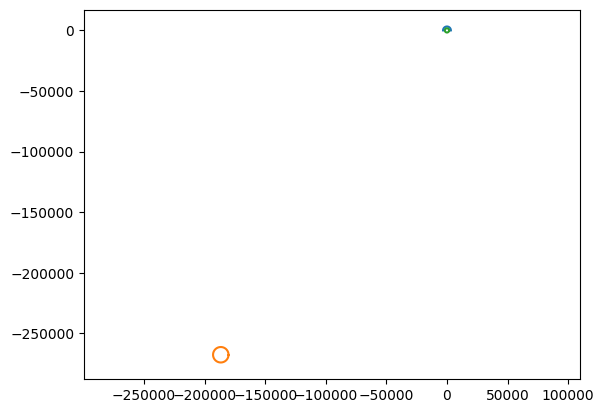

In [99]:
plt.plot(op.states[:,0], op.states[:,1])
plt.plot(*circle_points(Earth.radius, position=Earth.position[0:2]))
plt.plot(*circle_points(Luna.radius, position=Luna.position[0:2]))
# plt.plot(*circle_points(Sun.radius, Sun.position[0:2]))
plt.axis('equal')
plt.show()

## CR

Running CR where we have full moon in view 

In [100]:
# K_inv

# 30x20 cm (3000x2000 px) --> Center at 15,10 (1500x1000 px)
frame_pixels = np.array([3000, 2000])
# Assumes pixel spacing of 0.10um
mu = .1e-6
focus = 90e-3 # Focal length of 90mm according to https://ntrs.nasa.gov/api/citations/20200000353/downloads/20200000353.pdf
max_angle = np.tan(focus / (15e-2))
print(f"Max angle: {max_angle * RAD_TO_DEG}º")
dx = dy = focus/mu
alpha = 0
u_p = frame_pixels[0]/2
v_p = frame_pixels[1]/2

K_inv = np.array([
    [1/dx, -alpha/dx/dy, (alpha*v_p - dy*u_p)/dx/dy],
    [0, 1/dy, -v_p/dy],
    [0, 0, 1]
])

print(f"K_inv: {K_inv}")

a = b = c = 3e3 # km
print(f"a = {a} km")
print(f"b = {b} km")
print(f"c = {c} km")

Max angle: 39.19815172752946º
K_inv: [[ 1.11111111e-06  0.00000000e+00 -1.66666667e-03]
 [ 0.00000000e+00  1.11111111e-06 -1.11111111e-03]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]
a = 3000.0 km
b = 3000.0 km
c = 3000.0 km


In [ ]:
# Geometry for center image of 3-4-5
# # angle = np.atan(3/4) * RAD_TO_DEG
# apparent_radius_m = focus * np.tan(max_angle)
# apparent_radius_px = apparent_radius_m / mu
# print(f"Apparent radius on image plane: {apparent_radius_m}m = {apparent_radius_px}px")
# # apparent_radius_px = 675

Apparent radius on image plane: 0.07339737459612491m = 733973.7459612492px


In [ ]:
ratio = 675/np.sqrt()

In [102]:
# 5000 km away
# body_points = circle_points(apparent_radius_px, position=frame_pixels/2)
# body_points = circle_points(apparent_radius_px, position=(0,0))
body_points = circle_points(apparent_radius_px, position=(0,frame_pixels[1]/2))

N = 100
u_points = np.vstack((np.array(body_points), np.ones((100)))).T

# 10 pixels of covariance
R = np.array([
    [100, 0, 0],
    [0, 100, 0],
    [0, 0, 0]
])

u_noise = np.array([v + noise(R) for v in u_points])


# Makes sure it is in frame
u_in_frame = np.array([v + noise(R) for v in u_points 
                       if v[0] > 0 and v[0] < frame_pixels[0]
                       and v[1] > 0 and v[1] < frame_pixels[1]])
u_in_frame = u_noise

(0.0, 2000.0)

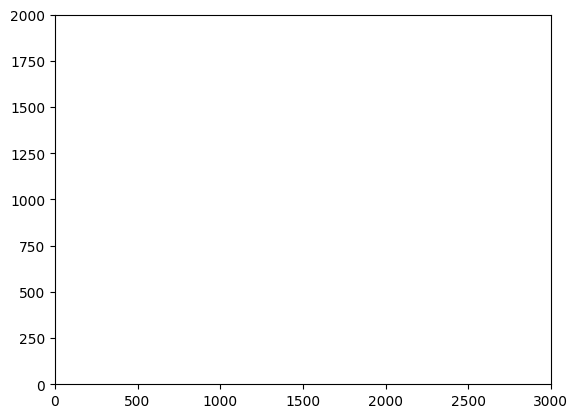

In [103]:
plt.scatter(u_in_frame[:,0], u_in_frame[:,1])
plt.xlim((0, 3000))
plt.ylim((0, 2000))

In [104]:
print(u_in_frame)

[[ 7.33953479e+05  9.99711844e+02  1.00000000e+00]
 [ 7.32522223e+05  4.70679565e+04  1.00000000e+00]
 [ 7.28173790e+05  9.29977117e+04  1.00000000e+00]
 [ 7.20983728e+05  1.38538545e+05  1.00000000e+00]
 [ 7.10921283e+05  1.83526936e+05  1.00000000e+00]
 [ 6.98042978e+05  2.27804823e+05  1.00000000e+00]
 [ 6.82438034e+05  2.71177663e+05  1.00000000e+00]
 [ 6.64116397e+05  3.13517533e+05  1.00000000e+00]
 [ 6.43189515e+05  3.54602444e+05  1.00000000e+00]
 [ 6.19695608e+05  3.94287769e+05  1.00000000e+00]
 [ 5.93811057e+05  4.32421508e+05  1.00000000e+00]
 [ 5.65533912e+05  4.68861744e+05  1.00000000e+00]
 [ 5.35037964e+05  5.03447499e+05  1.00000000e+00]
 [ 5.02436634e+05  5.36038377e+05  1.00000000e+00]
 [ 4.67859334e+05  5.66533396e+05  1.00000000e+00]
 [ 4.31404389e+05  5.94792344e+05  1.00000000e+00]
 [ 3.93285693e+05  6.20715746e+05  1.00000000e+00]
 [ 3.53607124e+05  6.44178283e+05  1.00000000e+00]
 [ 3.12493115e+05  6.65118223e+05  1.00000000e+00]
 [ 2.70202536e+05  6.83429090e+

In [105]:
cr_alg = ChristianRobinson(K_inv, a, b, c)

In [106]:
T_p_c = np.eye(3)
rc = cr_alg.run(u_in_frame, T_p_c)
print(rc)
print(norm(rc))

[-4.75961931e+00 -7.12863627e-03  4.74680243e+03]
4746.804817731614


In [107]:
# Calculator
# 1500*3000/675
# s_px = norm((1500, 1000))
s_px = 1500
s_r = s_px*mu
x = s_px*3000/675
z = x*focus/s_r
print(norm((x,z)))

print(x*1000/1802)
print(x*1500/1802)

4000005.555551698
3699.5930447650762
5549.389567147614
